In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [26]:
df = pd.read_csv("netflix_userbase.csv")
df.head()

,User ID,Subscription Type,Monthly Revenue,Join Date,Last Payment Date,Country,Age,Gender,Device,Plan Duration
0,1,Basic,10,15-01-22,10-06-23,United States,28,Male,Smartphone,1 Month
1,2,Premium,15,05-09-21,22-06-23,Canada,35,Female,Tablet,1 Month
2,3,Standard,12,28-02-23,27-06-23,United Kingdom,42,Male,Smart TV,1 Month
3,4,Standard,12,10-07-22,26-06-23,Australia,51,Female,Laptop,1 Month
4,5,Basic,10,01-05-23,28-06-23,Germany,33,Male,Smartphone,1 Month


In [27]:
df.info

<bound method DataFrame.info of       User ID Subscription Type  Monthly Revenue Join Date Last Payment Date  \
0           1             Basic               10  15-01-22          10-06-23   
1           2           Premium               15  05-09-21          22-06-23   
2           3          Standard               12  28-02-23          27-06-23   
3           4          Standard               12  10-07-22          26-06-23   
4           5             Basic               10  01-05-23          28-06-23   
...       ...               ...              ...       ...               ...   
2495     2496           Premium               14  25-07-22          12-07-23   
2496     2497             Basic               15  04-08-22          14-07-23   
2497     2498          Standard               12  09-08-22          15-07-23   
2498     2499          Standard               13  12-08-22          12-07-23   
2499     2500             Basic               15  13-08-22          12-07-23   

       

In [28]:
df.describe(include = "all")

,User ID,Subscription Type,Monthly Revenue,Join Date,Last Payment Date,Country,Age,Gender,Device,Plan Duration
count,2500.00000,2500,2500.000000,2500,2500,2500,2500.000000,2500,2500,2500
unique,NaN,3,NaN,300,26,10,NaN,2,4,1
top,NaN,Basic,NaN,05-11-22,28-06-23,United States,NaN,Female,Laptop,1 Month
freq,NaN,999,NaN,33,164,451,NaN,1257,636,2500
mean,1250.50000,NaN,12.508400,NaN,NaN,NaN,38.795600,NaN,NaN,NaN
std,721.83216,NaN,1.686851,NaN,NaN,NaN,7.171778,NaN,NaN,NaN
min,1.00000,NaN,10.000000,NaN,NaN,NaN,26.000000,NaN,NaN,NaN
25%,625.75000,NaN,11.000000,NaN,NaN,NaN,32.000000,NaN,NaN,NaN
50%,1250.50000,NaN,12.000000,NaN,NaN,NaN,39.000000,NaN,NaN,NaN
75%,1875.25000,NaN,14.000000,NaN,NaN,NaN,45.000000,NaN,NaN,NaN


In [29]:
df.isna().sum()

User ID              0
Subscription Type    0
Monthly Revenue      0
Join Date            0
Last Payment Date    0
Country              0
Age                  0
Gender               0
Device               0
Plan Duration        0
dtype: int64

In [30]:
df.duplicated().sum

<bound method Series.sum of 0       False
1       False
2       False
3       False
4       False
        ...  
2495    False
2496    False
2497    False
2498    False
2499    False
Length: 2500, dtype: bool>

In [32]:
df.columns = (
    df.columns
    .str.lower()
    .str.strip()
    .str.replace(" ", "_")
)
df.head()

,user_id,subscription_type,monthly_revenue,join_date,last_payment_date,country,age,gender,device,plan_duration
0,1,Basic,10,15-01-22,10-06-23,United States,28,Male,Smartphone,1 Month
1,2,Premium,15,05-09-21,22-06-23,Canada,35,Female,Tablet,1 Month
2,3,Standard,12,28-02-23,27-06-23,United Kingdom,42,Male,Smart TV,1 Month
3,4,Standard,12,10-07-22,26-06-23,Australia,51,Female,Laptop,1 Month
4,5,Basic,10,01-05-23,28-06-23,Germany,33,Male,Smartphone,1 Month


In [34]:
df['join_date'] = pd.to_datetime(df['join_date'], format='%d-%m-%y')
df['last_payment_date'] = pd.to_datetime(df['last_payment_date'], format='%d-%m-%y')

In [35]:
df['join_year_month'] = df['join_date'].dt.to_period('M').astype(str)

In [36]:
df.info()
df.describe(include='all')
df.isna().sum()
df.duplicated().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   user_id            2500 non-null   int64         
 1   subscription_type  2500 non-null   object        
 2   monthly_revenue    2500 non-null   int64         
 3   join_date          2500 non-null   datetime64[ns]
 4   last_payment_date  2500 non-null   datetime64[ns]
 5   country            2500 non-null   object        
 6   age                2500 non-null   int64         
 7   gender             2500 non-null   object        
 8   device             2500 non-null   object        
 9   plan_duration      2500 non-null   object        
 10  join_year_month    2500 non-null   object        
dtypes: datetime64[ns](2), int64(3), object(6)
memory usage: 215.0+ KB


np.int64(0)

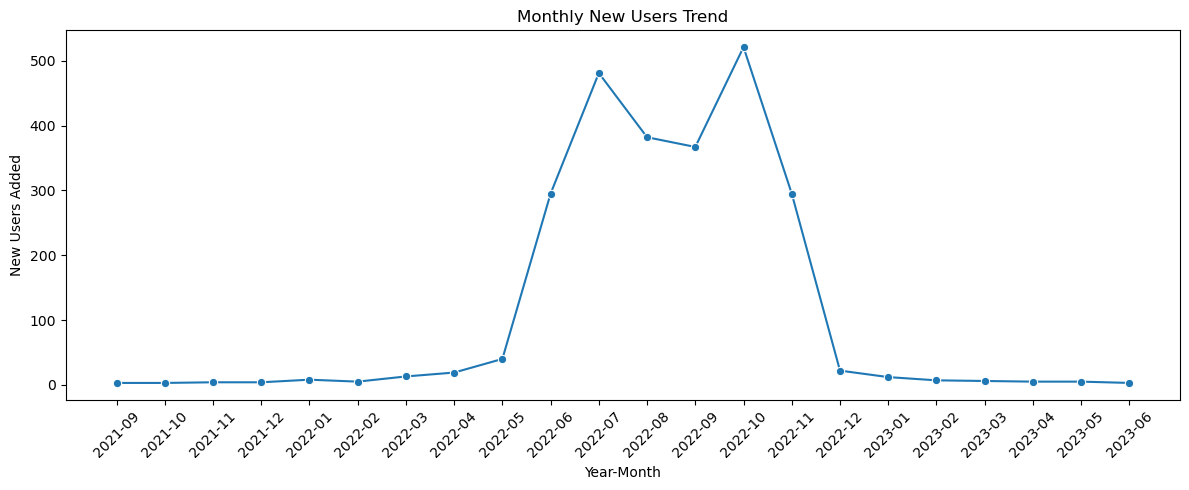

In [37]:
monthly_users = df.groupby('join_year_month').size().reset_index(name='new_users')

plt.figure(figsize=(12,5))
sns.lineplot(data=monthly_users, x='join_year_month', y='new_users', marker='o')
plt.xticks(rotation=45)
plt.title("Monthly New Users Trend")
plt.xlabel("Year-Month")
plt.ylabel("New Users Added")
plt.tight_layout()
plt.show()


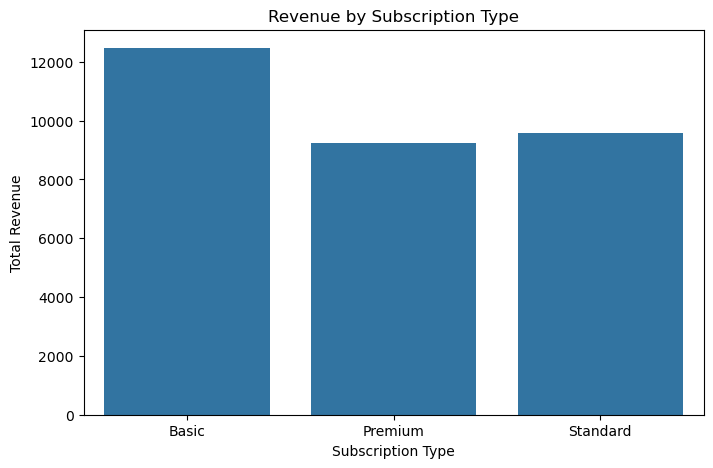

In [38]:
rev_by_plan = df.groupby('subscription_type')['monthly_revenue'].sum().reset_index()

plt.figure(figsize=(8,5))
sns.barplot(data=rev_by_plan, x='subscription_type', y='monthly_revenue')
plt.title("Revenue by Subscription Type")
plt.ylabel("Total Revenue")
plt.xlabel("Subscription Type")
plt.show()


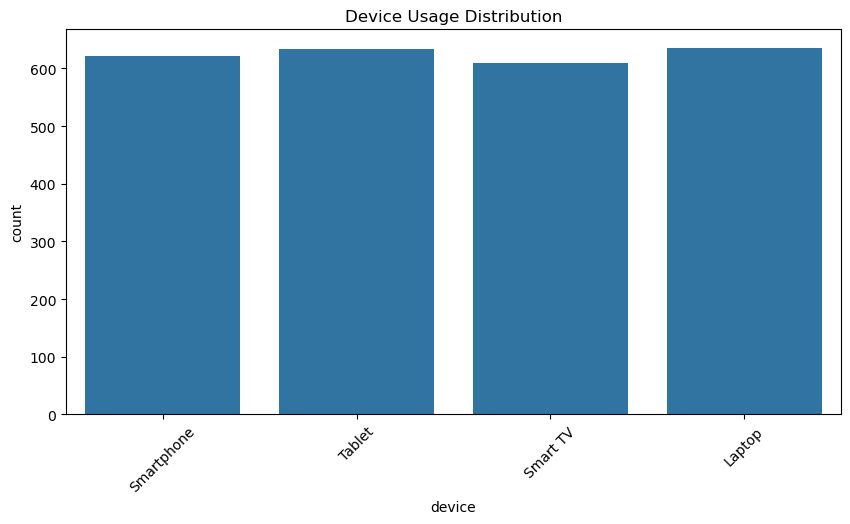

In [39]:
plt.figure(figsize=(10,5))
sns.countplot(data=df, x='device')
plt.xticks(rotation=45)
plt.title("Device Usage Distribution")
plt.show()


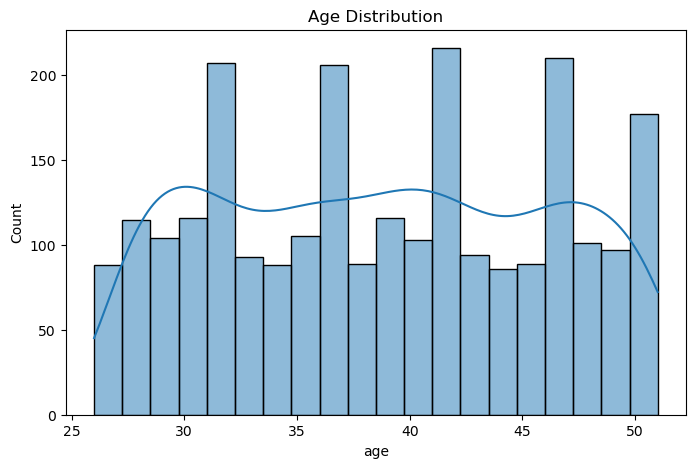

In [40]:
plt.figure(figsize=(8,5))
sns.histplot(df['age'], bins=20, kde=True)
plt.title("Age Distribution")
plt.show()
